Accuracy: 0.945

Classification Report

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       208
           1       0.96      0.93      0.94       192

    accuracy                           0.94       400
   macro avg       0.95      0.94      0.94       400
weighted avg       0.95      0.94      0.94       400


ROC AUC: 0.9939027443910257


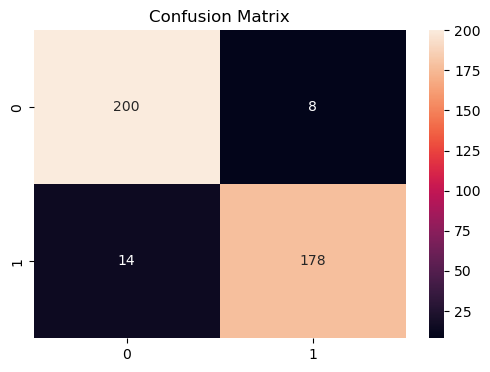


Top Features

                         Feature  Importance
23      num__DaysWithoutActivity    0.276418
19  num__ComplaintsFiledLastYear    0.137176
3               num__CreditScore    0.106878
11           num__AccountBalance    0.088571
15   num__MonthlyAccountSpending    0.040710
17       num__OnlineBankingUsage    0.029470
14     num__AvgTransactionAmount    0.027806
12              num__CreditLimit    0.027178
2              num__AnnualIncome    0.026972
22   num__CreditUtilizationRatio    0.026863
4          num__AccountAgeMonths    0.025984
13      num__MonthlyTransactions    0.025393
0                       num__Age    0.021144
16        num__ATMUsageFrequency    0.018569
18           num__MobileAppUsage    0.018359

Model Saved Successfully


In [2]:
import pandas as pd
import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# +++++++++++++++++++++++++
# Load Data
# +++++++++++++++++++++++++

df = pd.read_csv("Downloads/banking_customers.csv")

# +++++++++++++++++++++++++
# Features and Target
# +++++++++++++++++++++++++

X = df.drop(["Churn", "CustomerID"], axis=1)
y = df["Churn"]

# +++++++++++++++++++++++++
# Feature Lists
# +++++++++++++++++++++++++

num_feature = [
    'Age',
    'NumDependents',
    'AnnualIncome',
    'CreditScore',
    'AccountAgeMonths',
    'NumProducts',
    'HasCreditCard',
    'HasCheckingAccount',
    'HasSavingsAccount',
    'HasLoan',
    'HasMortgage',
    'AccountBalance',
    'CreditLimit',
    'MonthlyTransactions',
    'AvgTransactionAmount',
    'MonthlyAccountSpending',
    'ATMUsageFrequency',
    'OnlineBankingUsage',
    'MobileAppUsage',
    'ComplaintsFiledLastYear',
    'ComplaintsResolved',
    'ServiceCallsLastMonth',
    'CreditUtilizationRatio',
    'DaysWithoutActivity'
]

cat_feature = [
    'Gender',
    'MaritalStatus',
    'EducationLevel',
    'EmploymentStatus'
]

# +++++++++++++++++++++++++
# Pipelines
# +++++++++++++++++++++++++

numeric_trans = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
])

cat_trans = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder())
])

preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_trans, num_feature),
        ("cat", cat_trans, cat_feature)
])

# +++++++++++++++++++++++++
# Final Model
# +++++++++++++++++++++++++

model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier",RandomForestClassifier(n_estimators=200,random_state=42))
])

# +++++++++++++++++++++++++
# Split Data
# +++++++++++++++++++++++++

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# +++++++++++++++++++++++++
# Train
# +++++++++++++++++++++++++

model.fit(X_train, y_train)

# +++++++++++++++++++++++++
# Predict
# +++++++++++++++++++++++++

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# +++++++++++++++++++++++++
# Metrics
# +++++++++++++++++++++++++

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))
print("\nROC AUC:",roc_auc_score(y_test, y_prob))

# +++++++++++++++++++++++++
# Confusion Matrix
# +++++++++++++++++++++++++

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

# +++++++++++++++++++++++++
# Feature Importance
# +++++++++++++++++++++++++

rf = model.named_steps["classifier"]
feature_names = (model.named_steps["preprocessor"].get_feature_names_out())

importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance",ascending=False)

print("\nTop Features\n")
print(importance.head(15))

# +++++++++++++++++++++++++
# Save Model
# +++++++++++++++++++++++++

joblib.dump(model,"churn_model.pkl")

print("\nModel Saved Successfully")